In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

print("Path to dataset files:", path)

Path to dataset files: /home/nikita/.cache/kagglehub/datasets/sumanthvrao/daily-climate-time-series-data/versions/3


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv(path + '/DailyDelhiClimateTrain.csv')

In [3]:
df

,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000
...,...,...,...,...,...
1457,2016-12-28,17.217391,68.043478,3.547826,1015.565217
1458,2016-12-29,15.238095,87.857143,6.000000,1016.904762
1459,2016-12-30,14.095238,89.666667,6.266667,1017.904762
1460,2016-12-31,15.052632,87.000000,7.325000,1016.100000


In [4]:
df['age'] = df['date'].str[:4].astype(int)
df['month'] = df['date'].str[5:7].astype(int)
df['day'] = df['date'].str[8:10].astype(int)

df = df[(df['meanpressure'] >= 980) & (df['meanpressure'] <= 1100)]
df = df.reset_index(drop=True)

df['humidity'] = df['humidity'] / 50
df['wind_speed'] = df['wind_speed'] / 50
df['meanpressure'] = df['meanpressure'] / 1000

df['lag_1_humidity'] = df['humidity'].shift(1).fillna(0)
df['lag_2_humidity'] = df['lag_1_humidity'].shift(1).fillna(0)
df['lag_3_humidity'] = df['lag_2_humidity'].shift(1).fillna(0)

df['lag_1_wind_speed'] = df['wind_speed'].shift(1).fillna(0)
df['lag_2_wind_speed'] = df['lag_1_wind_speed'].shift(1).fillna(0)
df['lag_3_wind_speed'] = df['lag_2_wind_speed'].shift(1).fillna(0)

df['lag_1_meanpressure'] = df['meanpressure'].shift(1).fillna(0)
df['lag_2_meanpressure'] = df['lag_1_meanpressure'].shift(1).fillna(0)
df['lag_3_meanpressure'] = df['lag_2_meanpressure'].shift(1).fillna(0)

df['mean_humidity'] = (df['lag_1_humidity'] + df['lag_2_humidity'] + df['lag_3_humidity'] ) / 3
df['mean_wind_speed'] = (df['lag_1_wind_speed'] + df['lag_2_wind_speed'] + df['lag_3_wind_speed'] ) / 3
df['mean_meanpressure'] = (df['lag_1_meanpressure'] + df['lag_2_meanpressure'] + df['lag_3_meanpressure'] ) / 3

df

,date,meantemp,humidity,wind_speed,meanpressure,age,month,day,lag_1_humidity,lag_2_humidity,lag_3_humidity,lag_1_wind_speed,lag_2_wind_speed,lag_3_wind_speed,lag_1_meanpressure,lag_2_meanpressure,lag_3_meanpressure,mean_humidity,mean_wind_speed,mean_meanpressure
0,2013-01-01,10.000000,1.690000,0.000000,1.015667,2013,1,1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2013-01-02,7.400000,1.840000,0.059600,1.017800,2013,1,2,1.690000,0.000000,0.000000,0.000000,0.000000,0.000000,1.015667,0.000000,0.000000,0.563333,0.000000,0.338556
2,2013-01-03,7.166667,1.740000,0.092667,1.018667,2013,1,3,1.840000,1.690000,0.000000,0.059600,0.000000,0.000000,1.017800,1.015667,0.000000,1.176667,0.019867,0.677822
3,2013-01-04,8.666667,1.426667,0.024667,1.017167,2013,1,4,1.740000,1.840000,1.690000,0.092667,0.059600,0.000000,1.018667,1.017800,1.015667,1.756667,0.050756,1.017378
4,2013-01-05,6.000000,1.736667,0.074000,1.016500,2013,1,5,1.426667,1.740000,1.840000,0.024667,0.092667,0.059600,1.017167,1.018667,1.017800,1.668889,0.058978,1.017878
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1448,2016-12-28,17.217391,1.360870,0.070957,1.015565,2016,12,28,1.351000,1.497143,1.886000,0.166700,0.175684,0.181700,1.017200,1.016952,1.014350,1.578048,0.174695,1.016167
1449,2016-12-29,15.238095,1.757143,0.120000,1.016905,2016,12,29,1.360870,1.351000,1.497143,0.070957,0.166700,0.175684,1.015565,1.017200,1.016952,1.403004,0.137780,1.016573
1450,2016-12-30,14.095238,1.793333,0.125333,1.017905,2016,12,30,1.757143,1.360870,1.351000,0.120000,0.070957,0.166700,1.016905,1.015565,1.017200,1.489671,0.119219,1.016557
1451,2016-12-31,15.052632,1.740000,0.146500,1.016100,2016,12,31,1.793333,1.757143,1.360870,0.125333,0.120000,0.070957,1.017905,1.016905,1.015565,1.637115,0.105430,1.016792


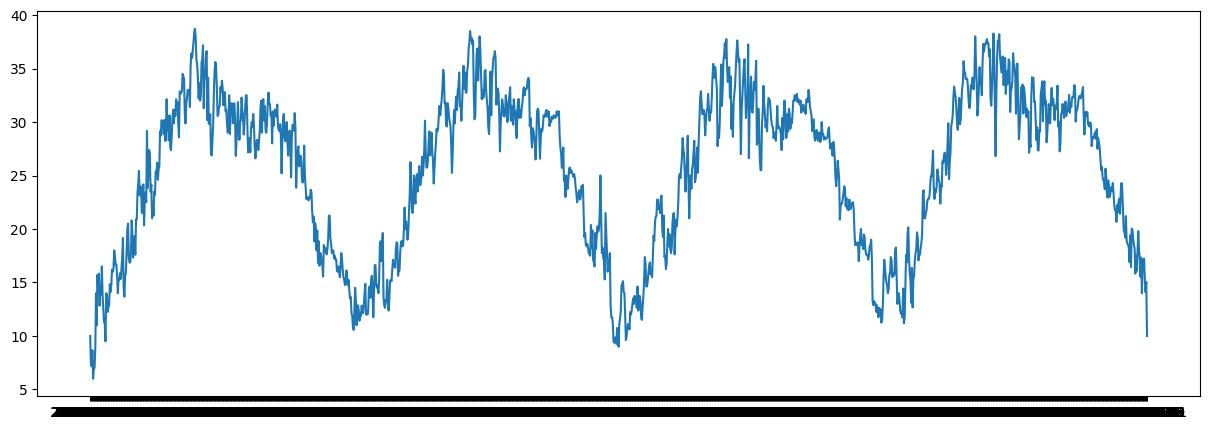

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['meantemp'])
plt.show()

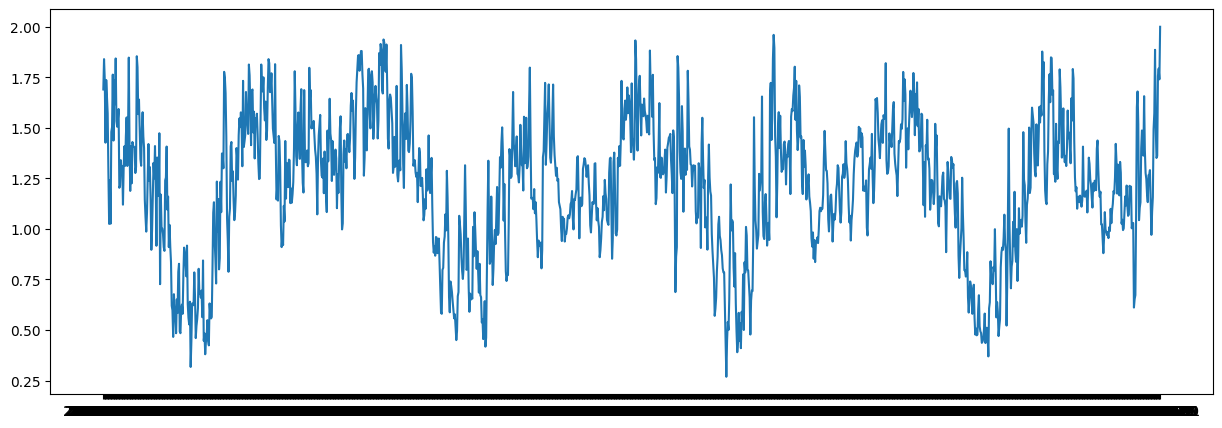

In [6]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['humidity'])
plt.show()

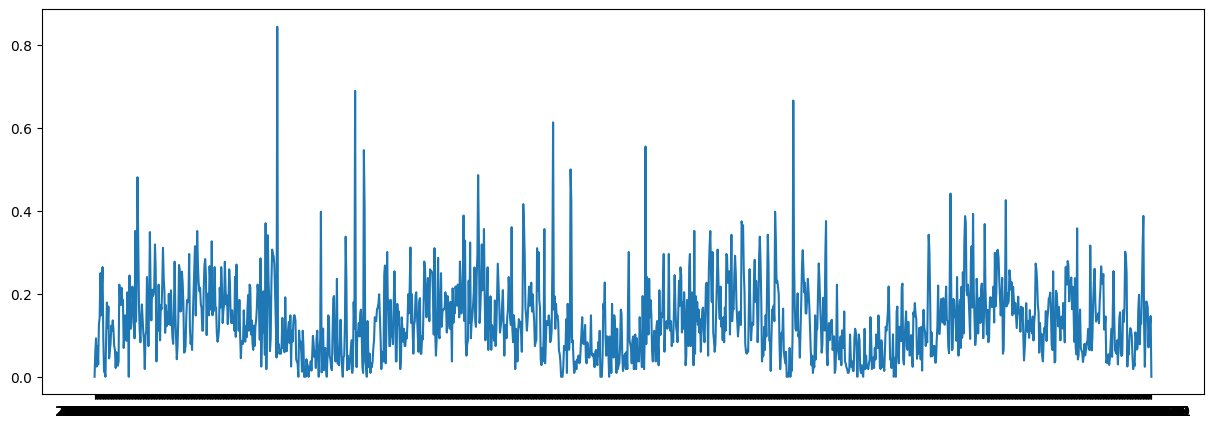

In [7]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['wind_speed'])
plt.show()

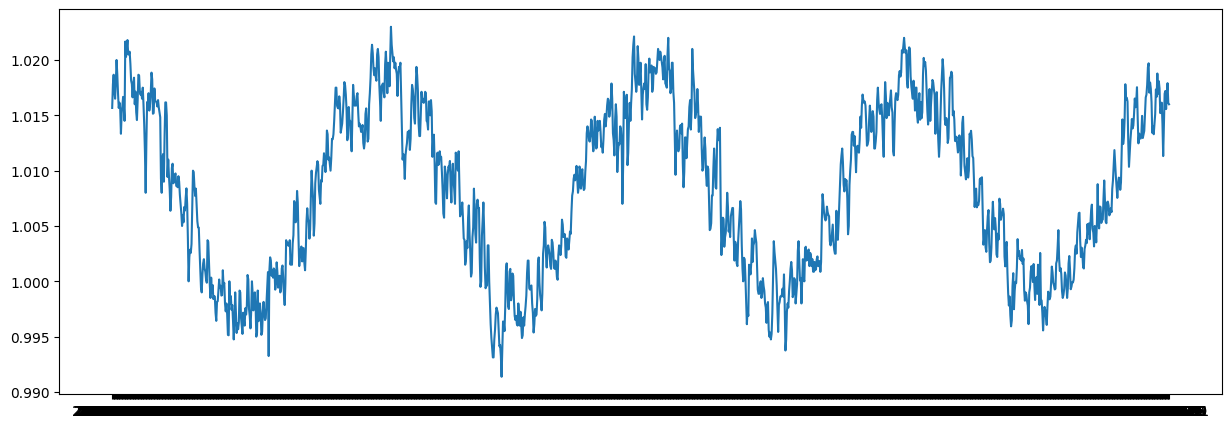

In [8]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['meanpressure'])
plt.show()

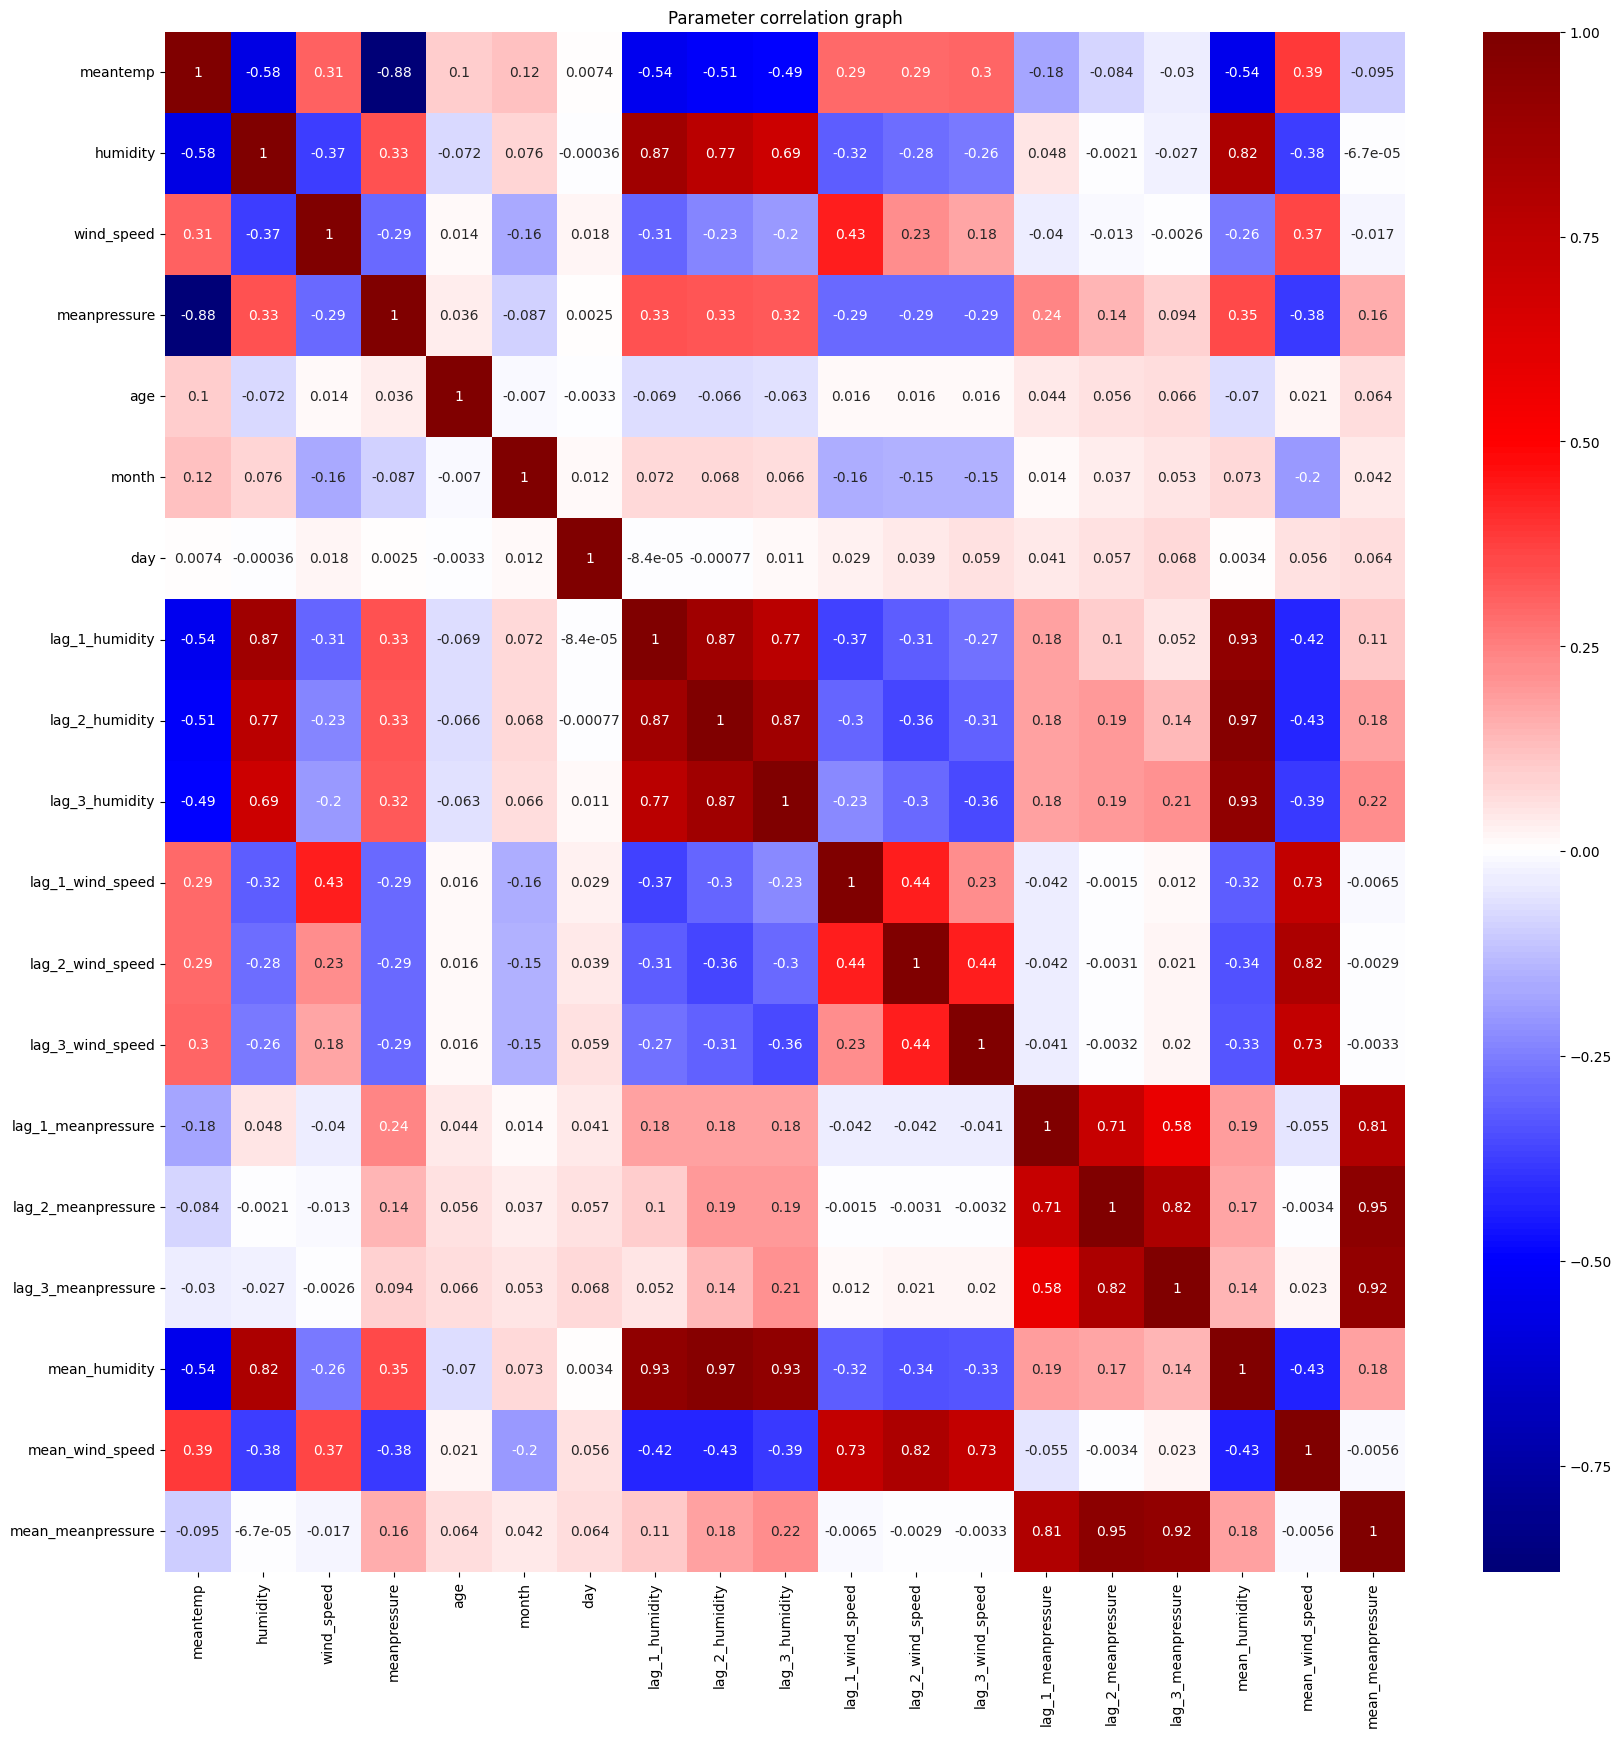

In [9]:
import seaborn as seaborn

df = df.drop(['date'], axis = 1)

plt.figure(figsize=(20, 20))
seaborn.heatmap(df.corr(), annot=True, cmap='seismic', center=0)
plt.title('Parameter correlation graph')
plt.show()

In [67]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.stattools import adfuller
from pmdarima.arima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
import sklearn.metrics as metric
from statsmodels.tsa.stattools import acf
from scipy.stats import pearsonr
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.vector_ar.var_model import VAR

In [89]:
def train_predict_arima(predicted_data, model, predicted_data_2 = None):
    series = df[predicted_data]
    train_size = int(len(series) * 0.8)
    train, test = series[:train_size], series[train_size:]

    print('Model is', model)
    
    if model == 'arima':
        seas = 0
        auto_ar = auto_arima(series, seasonal=False, trace=False)
        arima_model = ARIMA(train, order=auto_ar.order)
        arima_model = arima_model.fit()
    
    elif model == 'sarimax':
        seas = 12
        auto_ar = auto_arima(series, seasonal=True, m=seas, # Weeky cycle (5 days) for daily data
            trace=False, stepwise=True, # Faster optimization
            suppress_warnings=True, error_action="ignore")
        arima_model = SARIMAX(train, order=auto_ar.order, # Non-seasonal (p,d,q)
            seasonal_order=auto_ar.order+(seas,),      # Seasonal (P,D,Q,S)
            enforce_stationarity=False)
        arima_model = arima_model.fit()
    
    elif model == 'varima':

        cols = [predicted_data, predicted_data_2]
        data_multi = df[cols]

        train_size_multi = int(len(data_multi) * 0.8)
        train_multi, test_multi = data_multi.iloc[:train_size_multi], data_multi.iloc[train_size_multi:]
        
        # Подбор порядка VAR по AIC (макс. лагов 10)
        var_model = VAR(train_multi)
        var_order = var_model.select_order(maxlags=10)
        p = var_order.aic
        if p is None or p == 0:
            p = 1
        print(f"Selected VAR order: {p}")
        
        var_fitted = var_model.fit(p)
        
        fitted_multi = var_fitted.fittedvalues
        predicted_full = pd.Series(index=train_multi.index, dtype=float)
        predicted_full.iloc[p:] = fitted_multi[predicted_data].values
        predicted = predicted_full
        
        last_obs = train_multi.iloc[-p:].values
        forecasts_list = []
        for i in range(len(test_multi)):
            next_forecast = var_fitted.forecast(y=last_obs, steps=1)
            forecasts_list.append(next_forecast[0])
            actual = test_multi.iloc[i].values
            last_obs = np.vstack([last_obs[1:], actual])
        forecasts_multi = np.array(forecasts_list)
        target_index = cols.index(predicted_data)
        forecasts = pd.Series(forecasts_multi[:, target_index], index=test_multi.index)
        
        arima_model = var_fitted
        seas = p  
        
    else:
        return None

    if model in ['arima', 'sarimax']:
        predicted = arima_model.predict(start=1, end=len(train))

        results = arima_model
        forecasts = [results.forecast(steps=1).iloc[0]] 
    
        for i in range(len(test)):
            results = results.append(test.iloc[i:i+1], refit=False)
    
            forecasts.append(results.forecast(steps=1).iloc[0])

        forecasts = forecasts[:-1] 

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    ax1.plot(train.index[seas:], train[seas:], label='Train')
    ax1.plot(train.index[seas:], predicted[seas:], label='Predict', linestyle='--')
    ax1.set_title(f'Train vs Predict (r2_score = {round(metric.r2_score(predicted[seas:], train[seas:]), 4)})')
    ax1.legend()

    ax2.plot(test.index[seas:], test[seas:], label="Test")
    ax2.plot(test.index[seas:], forecasts[seas:], label="Forecast", linestyle="--")
    ax2.set_title(f'Test vs Forecast (r2_score = {round(metric.r2_score(forecasts[seas:], test[seas:]), 4)})')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # results.plot_diagnostics(figsize=(8,8))
    # plt.show()


predict: meantemp
Model is arima


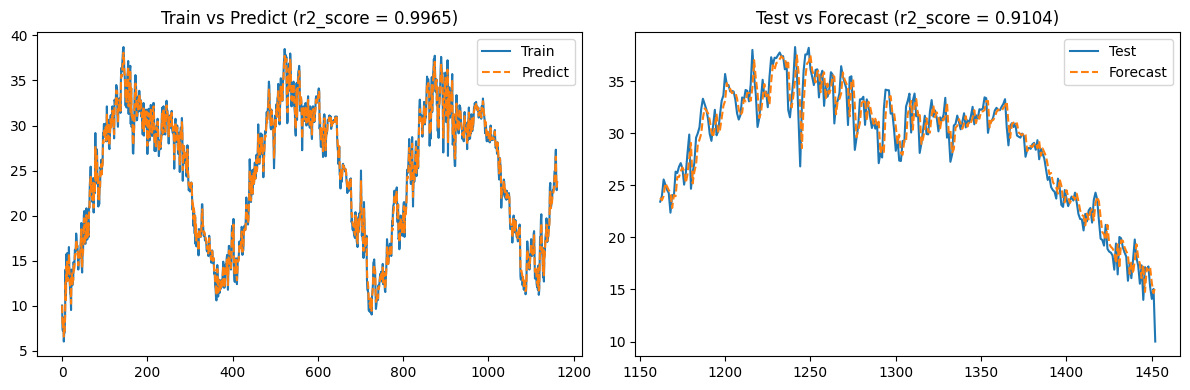

predict: humidity
Model is arima


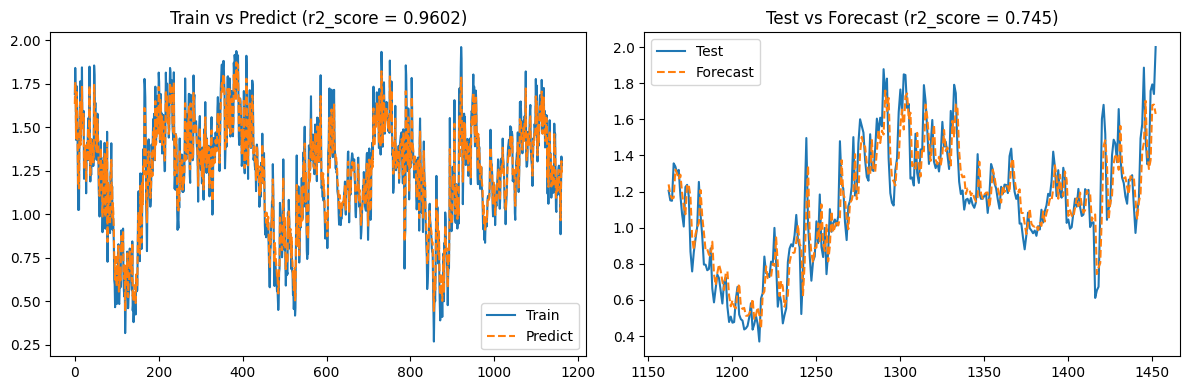

predict: wind_speed
Model is arima


/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


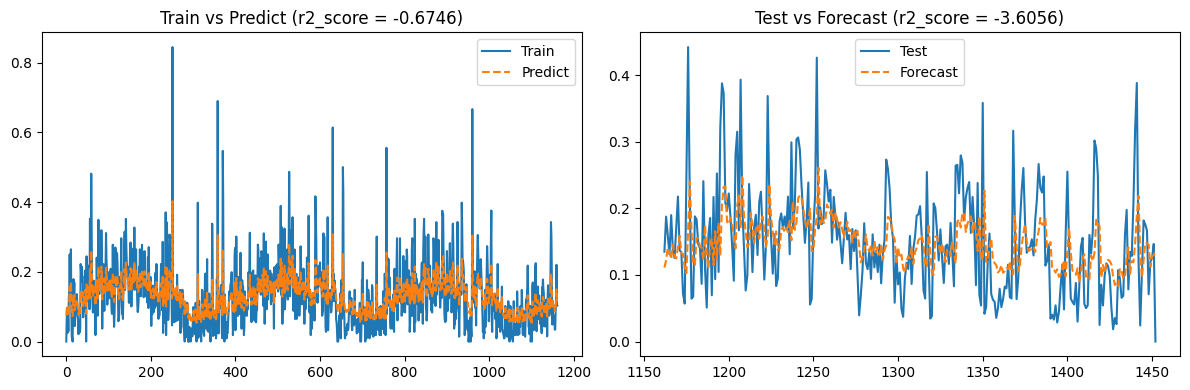

predict: meanpressure
Model is arima


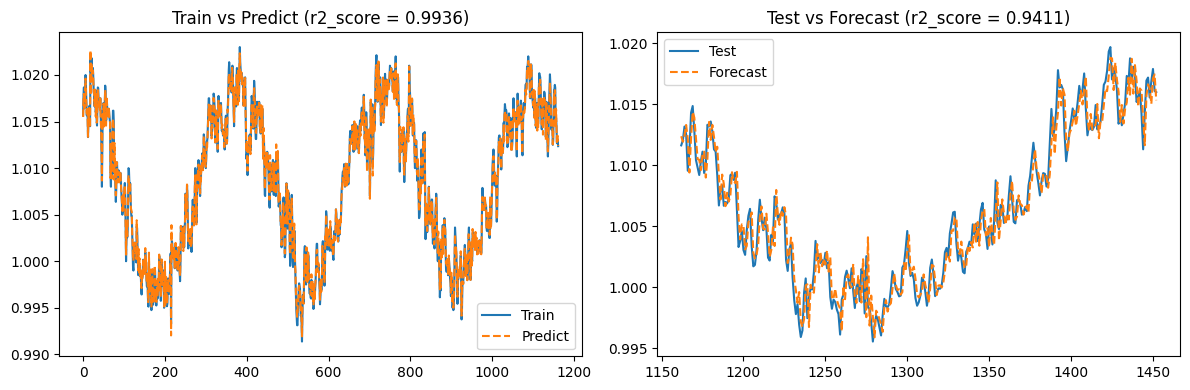

predict: meantemp
Model is sarimax


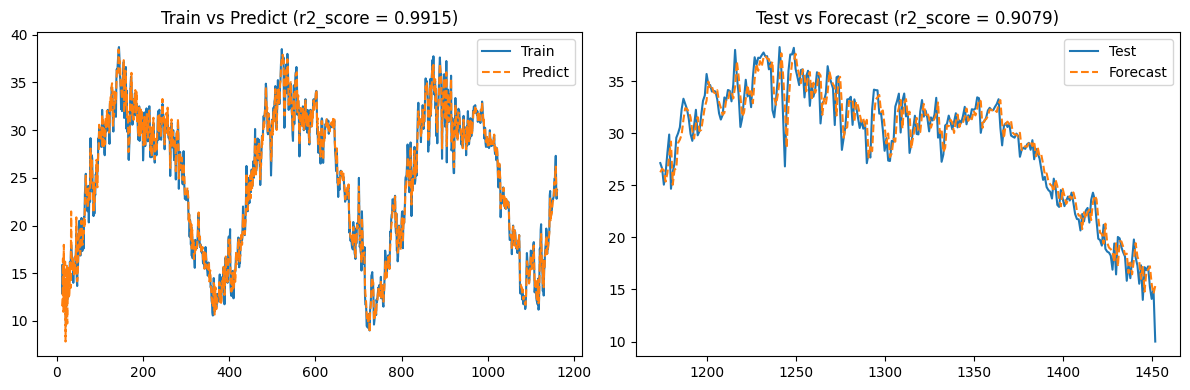

predict: humidity
Model is sarimax


/home/nikita/anaconda3/envs/tf-gpu/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


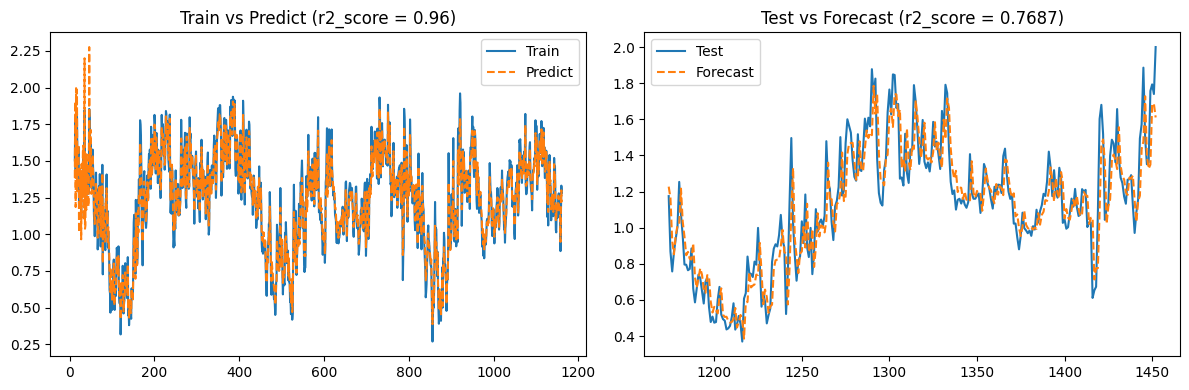

predict: wind_speed
Model is sarimax


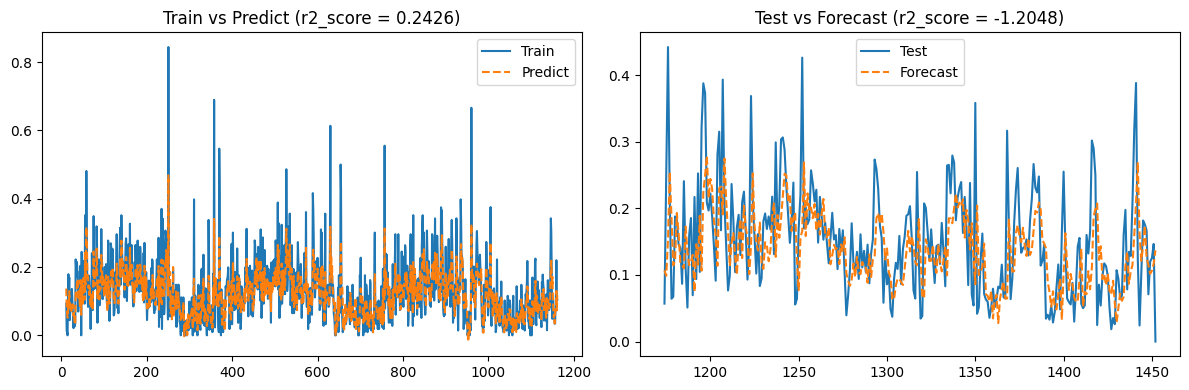

predict: meanpressure
Model is sarimax


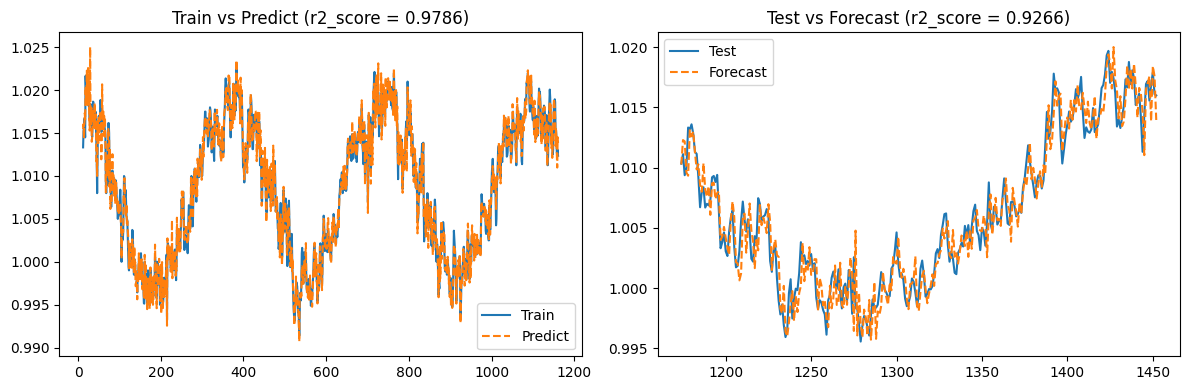

predict: meantemp and humidity
Model is varima
Selected VAR order: 6


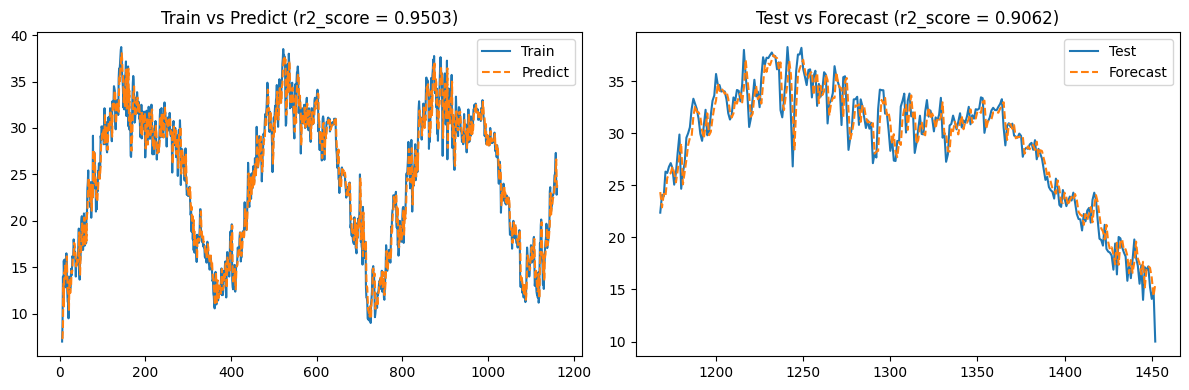

predict: humidity and wind_speed
Model is varima
Selected VAR order: 6


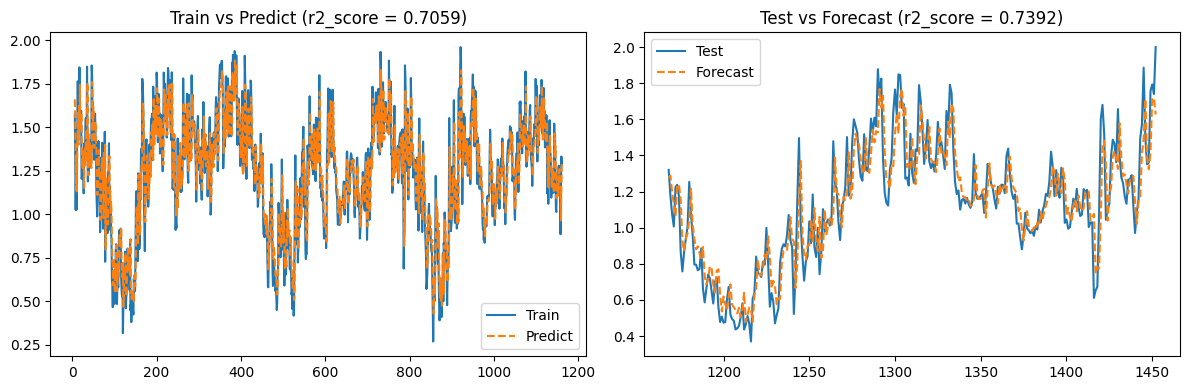

predict: wind_speed and meanpressure
Model is varima
Selected VAR order: 10


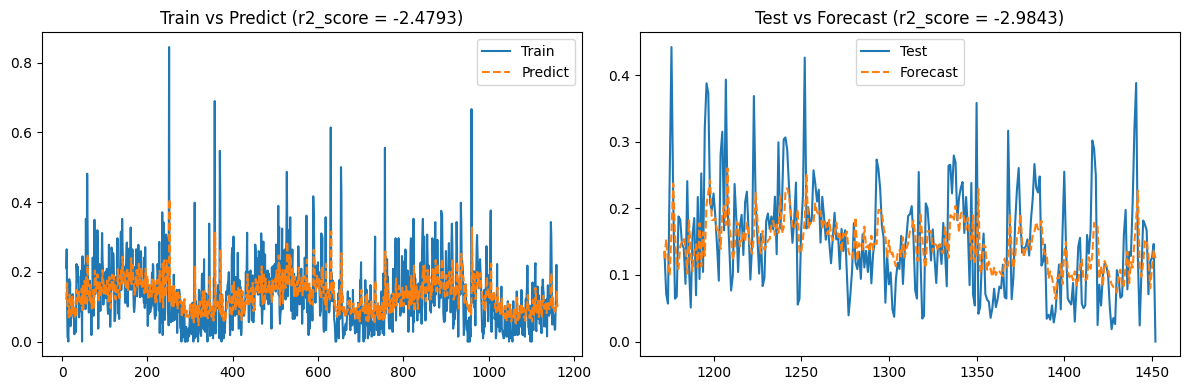

In [90]:
res_cols = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']

for res in res_cols:
    print('predict:', res)
    train_predict_arima(res, 'arima')

for res in res_cols:
    print('predict:', res)
    train_predict_arima(res, 'sarimax')

for i in range(len(res_cols)-1):
    print('predict:', res_cols[i], 'and', res_cols[i+1])
    train_predict_arima(res_cols[i], 'varima',res_cols[i+1])